In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
!pip install ultralytics -q
from ultralytics import YOLO
from pathlib import Path

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
from pathlib import Path

for p in Path("/kaggle/input").rglob("best.pt"):
    print(p)

/kaggle/input/models/harshitsingh09/yolov8-license-plate-detector/pytorch/default/1/best.pt


In [6]:
PLATE_MODEL = "/kaggle/input/models/harshitsingh09/yolov8-license-plate-detector/pytorch/default/1/best.pt"

plate_model = YOLO(PLATE_MODEL)

print("License Plate Detector Loaded!")

License Plate Detector Loaded!


In [8]:
VIDEO_PATH="/kaggle/input/datasets/farzadnekouei/license-plate-recognition-for-red-light-violation/traffic_video_modified.mp4"

(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

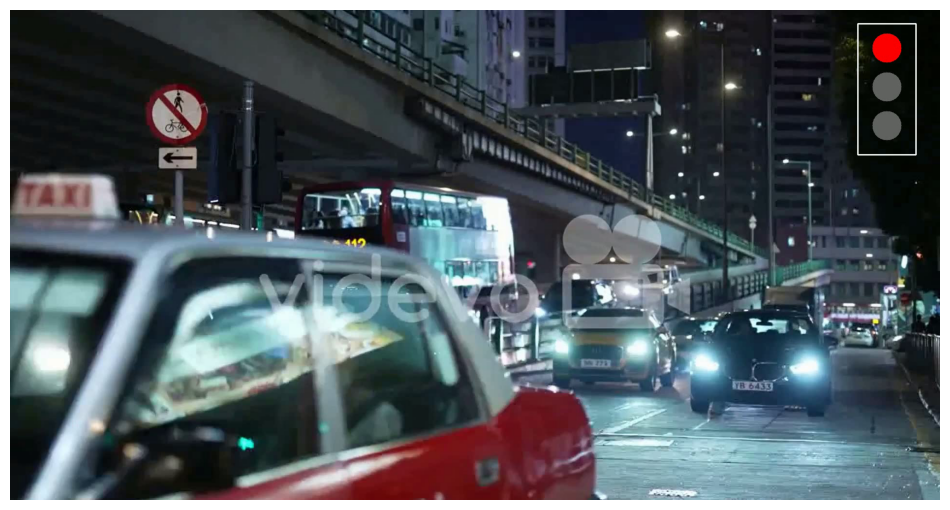

In [34]:
cap = cv2.VideoCapture(VIDEO_PATH)

cap.set(cv2.CAP_PROP_POS_FRAMES, 300)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(frame_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

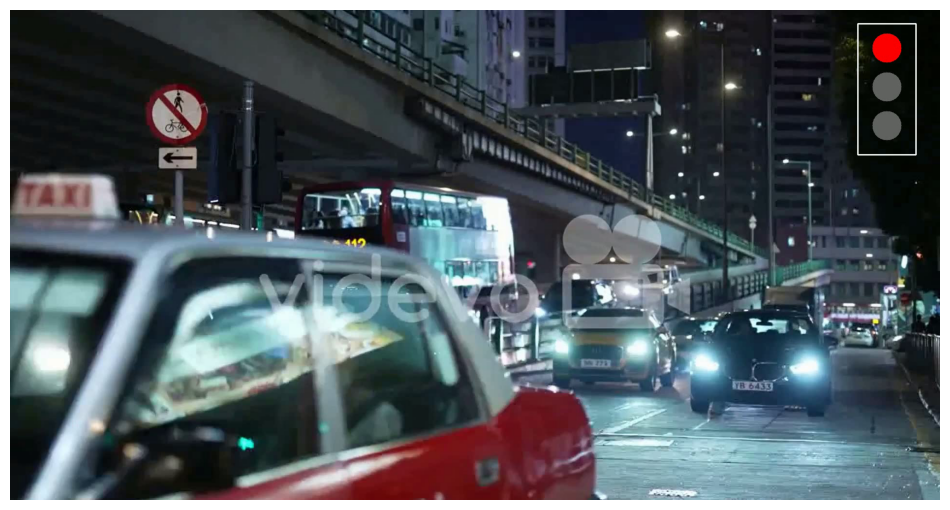

In [35]:
results = plate_model.predict(
    frame,
    conf=0.30
)

annotated = results[0].plot()

plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [36]:
results = plate_model.predict(
    frame,
    conf=0.1,          # Lower threshold
    imgsz=1280,
    verbose=False
)

print("Detections:", len(results[0].boxes))

if len(results[0].boxes):
    for box in results[0].boxes:
        print(box.xyxy[0].tolist(), float(box.conf))

Detections: 2
[1489.74609375, 766.08837890625, 1578.8038330078125, 789.492919921875] 0.5240017771720886
[733.755615234375, 52.83812713623047, 803.9306030273438, 121.803955078125] 0.3003547489643097


(np.float64(-0.5), np.float64(1919.5), np.float64(1011.5), np.float64(-0.5))

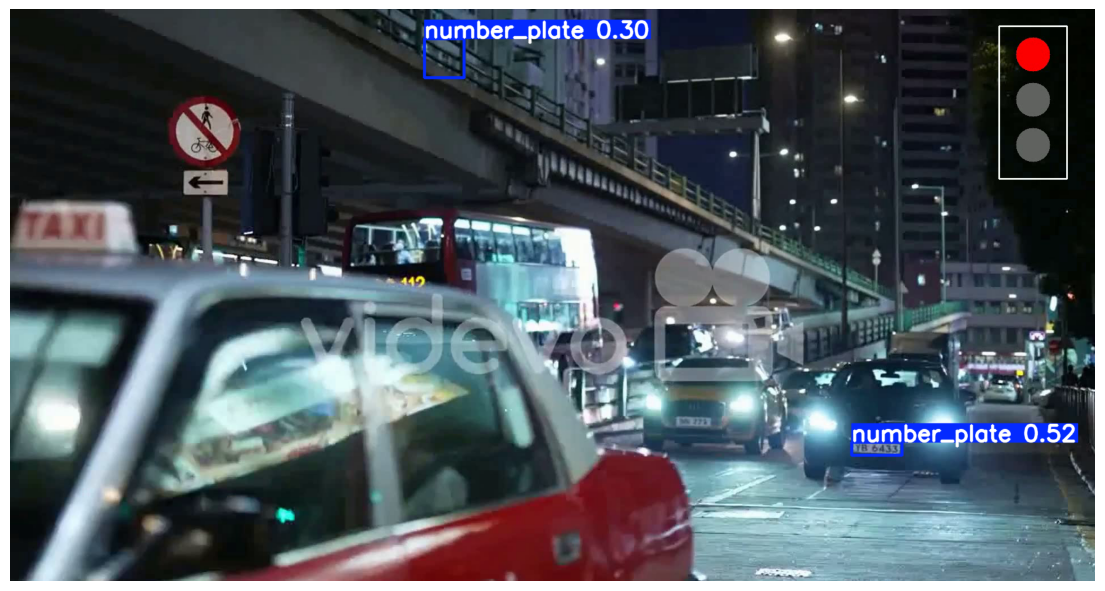

In [37]:
annotated = results[0].plot()

plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")

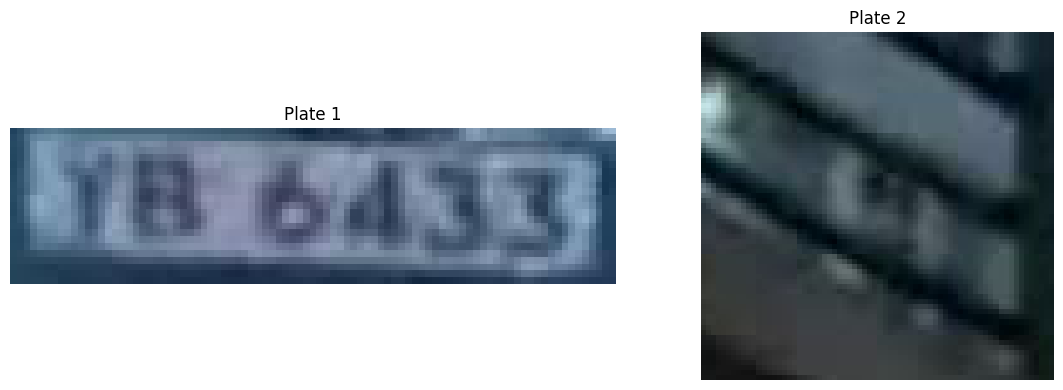

In [38]:
result = results[0]

plt.figure(figsize=(12,4))

for i, box in enumerate(result.boxes):

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate = frame[y1:y2, x1:x2]

    plt.subplot(1, len(result.boxes), i+1)

    plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))

    plt.title(f"Plate {i+1}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [39]:
#Prespective correction 
import cv2
import numpy as np

def perspective_correction(plate):

    gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if not contours:
        return plate

    cnt = max(contours, key=cv2.contourArea)

    rect = cv2.minAreaRect(cnt)

    angle = rect[-1]

    if angle < -45:
        angle += 90

    h, w = plate.shape[:2]

    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)

    corrected = cv2.warpAffine(
        plate,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return corrected

In [40]:
##image enhancement 
def enhance_plate(img):

    img = cv2.resize(
        img,
        None,
        fx=3,
        fy=3,
        interpolation=cv2.INTER_CUBIC
    )

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    gray = clahe.apply(gray)

    gray = cv2.fastNlMeansDenoising(
        gray,
        None,
        10,
        7,
        21
    )

    kernel = np.array([
        [0,-1,0],
        [-1,5,-1],
        [0,-1,0]
    ])

    gray = cv2.filter2D(gray,-1,kernel)

    return gray

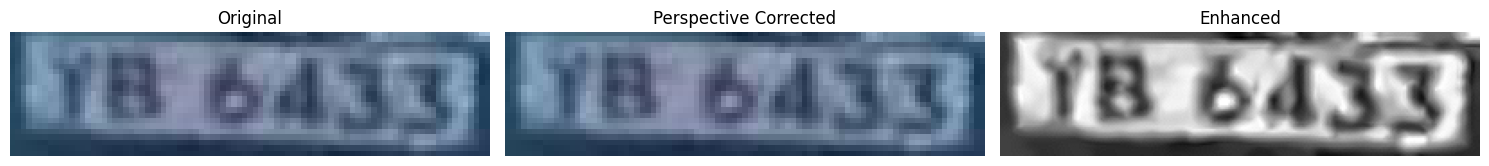

In [41]:
#proces every detected plate 
plt.figure(figsize=(15, 5 * len(results[0].boxes)))

row = 1

for box in results[0].boxes:

    if float(box.conf) < 0.45:
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate = frame[y1:y2, x1:x2]

    corrected = perspective_correction(plate)

    enhanced = enhance_plate(corrected)

    # Original
    plt.subplot(len(results[0].boxes), 3, row)
    plt.imshow(cv2.cvtColor(plate, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")

    # Perspective corrected
    plt.subplot(len(results[0].boxes), 3, row + 1)
    plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
    plt.title("Perspective Corrected")
    plt.axis("off")

    # Enhanced
    plt.subplot(len(results[0].boxes), 3, row + 2)
    plt.imshow(enhanced, cmap="gray")
    plt.title("Enhanced")
    plt.axis("off")

    row += 3

plt.tight_layout()
plt.show()

In [44]:
!git clone https://github.com/baudm/parseq.git

Cloning into 'parseq'...
remote: Enumerating objects: 612, done.
remote: Counting objects: 100% (311/311), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 612 (delta 243), reused 193 (delta 193), pack-reused 301 (from 2)
Receiving objects: 100% (612/612), 1.34 MiB | 6.57 MiB/s, done.
Resolving deltas: 100% (344/344), done.


In [45]:
%cd parseq

!pip install -q -r requirements/core.cpu.txt

!pip install -e .

/kaggle/working/parseq
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements/core.cpu.txt'
Obtaining file:///kaggle/working/parseq
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for strhub (pyproject.toml) ... done
  Created wheel for strhub: filename=strhub-1.2.0-0.editable-py3-none-any.whl size=17097 sha256=3bdce74ddc1d4964183bc8b78eacc7140b737c155e3d68fff6eafcde45cd9aab
  Stored in directory: /tmp/pip-ephem-wheel-cache-fdrghbsi/wheels/0c/a7/8a/3810277eec61866f68982f3e03ebbbea4d26e3c1470b6facae
Successfully built strhub


In [46]:
import torch

parseq = torch.hub.load(
    "baudm/parseq",
    "parseq",
    pretrained=True
).eval()

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/baudm/parseq/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://github.com/baudm/parseq/releases/download/v1.0.0/parseq-bb5792a6.pt" to /root/.cache/torch/hub/checkpoints/parseq-bb5792a6.pt


100%|██████████| 91.0M/91.0M [00:00<00:00, 168MB/s] 


In [48]:
!pip install -q lmdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.7/344.7 kB 5.6 MB/s eta 0:00:00:00:01


In [49]:
!pip install -q lmdb timm pytorch-lightning nltk

In [50]:
from PIL import Image
from strhub.data.module import SceneTextDataModule

transform = SceneTextDataModule.get_transform(
    parseq.hparams.img_size
)

In [51]:
plate_rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

img = Image.fromarray(plate_rgb)

img = transform(img).unsqueeze(0)

In [52]:
with torch.no_grad():

    logits = parseq(img)

    pred = logits.softmax(-1)

    label, confidence = parseq.tokenizer.decode(pred)

print("Plate:", label[0])
print("Confidence:", confidence[0])

Plate: YB6433
Confidence: tensor([0.9839, 0.9939, 0.9984, 0.9994, 0.9994, 0.9980, 0.9939])


In [54]:
enhanced_plates = []

for box in results[0].boxes:

    if float(box.conf) < 0.45:
        continue

    x1, y1, x2, y2 = map(int, box.xyxy[0])

    plate = frame[y1:y2, x1:x2]

    corrected = perspective_correction(plate)

    enhanced = enhance_plate(corrected)

    enhanced_plates.append(enhanced)

IndexError: list index out of range

In [53]:
results = []

for plate in enhanced_plates:

    plate_rgb = cv2.cvtColor(plate, cv2.COLOR_GRAY2RGB)

    img = Image.fromarray(plate_rgb)

    img = transform(img).unsqueeze(0)

    with torch.no_grad():

        logits = parseq(img)

        pred = logits.softmax(-1)

        label, confidence = parseq.tokenizer.decode(pred)

    results.append({
        "plate": label[0],
        "confidence": float(confidence[0])
    })

print(results)

NameError: name 'enhanced_plates' is not defined